# Yellow Taxi EDA

This notebook reads the exported analytical outputs produced by `aggregate_yellow_taxi.py` and focuses on two areas:
- curated-data quality after cleaning
- hourly demand patterns that support the forecasting goal


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "output").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPORT_BASE = PROJECT_ROOT / "output" / "eda" / "yellow"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
EXPORT_BASE


WindowsPath('c:/Users/shrut/OneDrive/Desktop/SEM-2/BigData/Project/Data228GroupProject/output/eda/yellow')

## Load exported datasets

Each dataset is written as a Spark CSV folder with a single `part-*.csv` file. If one of these is missing, rerun the aggregation Spark job first.


In [2]:
def load_export(dataset_name: str) -> pd.DataFrame:
    export_dir = EXPORT_BASE / dataset_name
    part_files = sorted(export_dir.glob("part-*.csv"))
    if not part_files:
        raise FileNotFoundError(
            f"No part file found for {dataset_name} under {export_dir}. "
            "Rerun jobs/aggregate_yellow_taxi.py first."
        )
    return pd.read_csv(part_files[0])


def normalize_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().map({"true": True, "false": False})


curated_profile = load_export("curated_feature_profile")
cleaning_summary = load_export("cleaning_summary")
overall_hourly = load_export("overall_hourly_demand")
borough_hourly = load_export("borough_hourly_demand")
weekday_weekend = load_export("weekday_weekend_demand")
weekday_hourly = load_export("weekday_hourly_demand")
trip_metrics = load_export("trip_metrics_by_hour")
top_pickup = load_export("top_pickup_zones")
top_dropoff = load_export("top_dropoff_zones")

overall_hourly["pickup_hour_ts"] = pd.to_datetime(overall_hourly["pickup_hour_ts"])
borough_hourly["pickup_hour_ts"] = pd.to_datetime(borough_hourly["pickup_hour_ts"])
weekday_weekend["is_weekend"] = normalize_bool(weekday_weekend["is_weekend"])
weekday_hourly["is_weekend"] = normalize_bool(weekday_hourly["is_weekend"])

{
    "curated_profile": curated_profile.shape,
    "cleaning_summary": cleaning_summary.shape,
    "overall_hourly": overall_hourly.shape,
    "borough_hourly": borough_hourly.shape,
    "weekday_weekend": weekday_weekend.shape,
    "weekday_hourly": weekday_hourly.shape,
    "trip_metrics": trip_metrics.shape,
    "top_pickup": top_pickup.shape,
    "top_dropoff": top_dropoff.shape,
}


{'curated_profile': (31, 7),
 'cleaning_summary': (4, 2),
 'overall_hourly': (744, 7),
 'borough_hourly': (4739, 8),
 'weekday_weekend': (48, 3),
 'weekday_hourly': (168, 4),
 'trip_metrics': (24, 6),
 'top_pickup': (20, 5),
 'top_dropoff': (20, 5)}

## Cleaning impact and curated feature quality

These tables summarize how many rows were removed during cleaning and how much missing data remains in the curated layer used for all downstream analysis.


In [3]:
cleaning_summary['value'] = cleaning_summary['value'].astype(int)
display(cleaning_summary)
display(curated_profile.sort_values(["null_count", "feature_name"], ascending=[False, True]).head(15))


,metric,value
0,raw_row_count,3066766
1,curated_row_count,3040551
2,removed_row_count,26215
3,removed_pct,0


,approx_distinct_count,data_type,feature_name,non_null_count,null_count,null_pct,row_count
0,7,double,RatecodeID,2968882,71669,2.3571,3040551
1,3,double,airport_fee,2968882,71669,2.3571,3040551
2,3,double,congestion_surcharge,2968882,71669,2.3571,3040551
3,10,double,passenger_count,2968882,71669,2.3571,3040551
4,264,bigint,DOLocationID,3040551,0,0.0000,3040551
5,259,bigint,PULocationID,3040551,0,0.0000,3040551
6,2,bigint,VendorID,3040551,0,0.0000,3040551
7,6189,double,base_passenger_fare,3040551,0,0.0000,3040551
8,34,date,dropoff_date,3040551,0,0.0000,3040551
9,1637350,timestamp,dropoff_datetime,3040551,0,0.0000,3040551


## Overall hourly demand

This is the simplest view of the forecasting target: total trip demand by pickup hour.


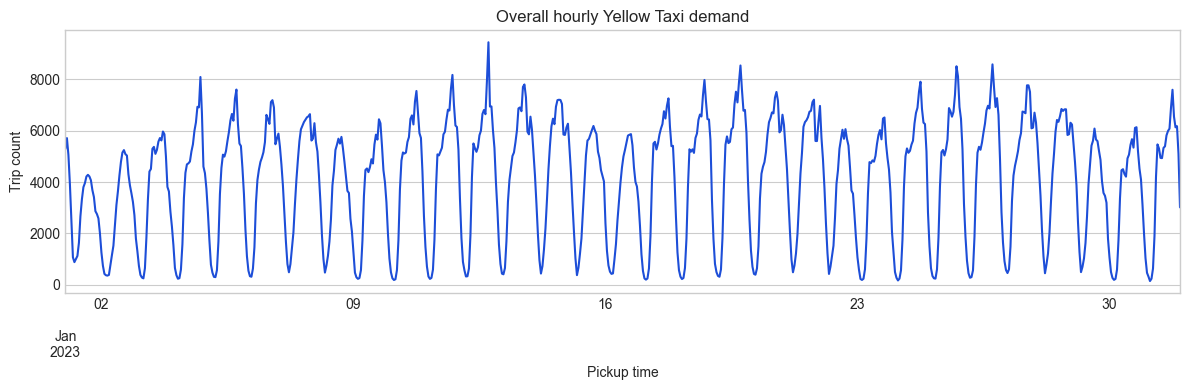

In [4]:
ax = overall_hourly.plot(
    x="pickup_hour_ts",
    y="trip_count",
    figsize=(12, 4),
    title="Overall hourly Yellow Taxi demand",
    legend=False,
    color="#1d4ed8",
)
ax.set_xlabel("Pickup time")
ax.set_ylabel("Trip count")
plt.tight_layout()


## Borough-level demand over time

This helps show where demand is concentrated and whether different boroughs have distinct hourly behavior.


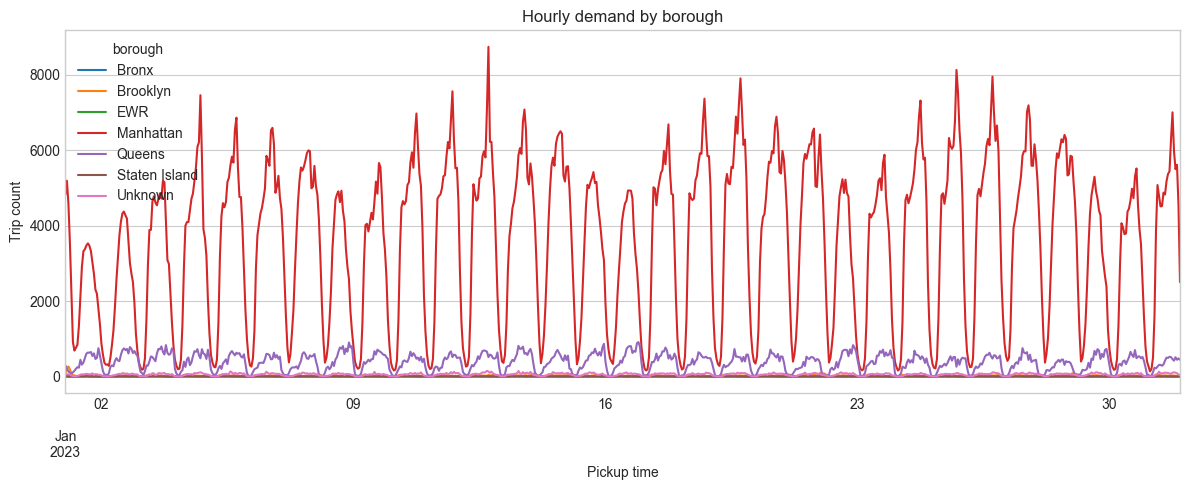

In [5]:
borough_pivot = borough_hourly.pivot_table(
    index="pickup_hour_ts",
    columns="borough",
    values="trip_count",
    aggfunc="sum",
).fillna(0)

ax = borough_pivot.plot(figsize=(12, 5), title="Hourly demand by borough")
ax.set_xlabel("Pickup time")
ax.set_ylabel("Trip count")
plt.tight_layout()


## Weekday and weekend demand patterns

These views justify time-based features such as hour-of-day and weekend indicators.


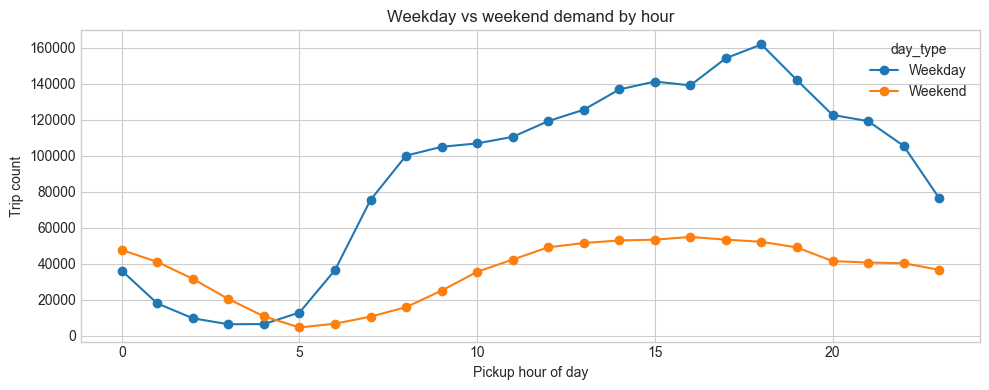

In [6]:
weekday_weekend["day_type"] = weekday_weekend["is_weekend"].map({True: "Weekend", False: "Weekday"})
pivot = weekday_weekend.pivot(index="pickup_hour", columns="day_type", values="trip_count")
ax = pivot.plot(figsize=(10, 4), marker="o", title="Weekday vs weekend demand by hour")
ax.set_xlabel("Pickup hour of day")
ax.set_ylabel("Trip count")
plt.tight_layout()


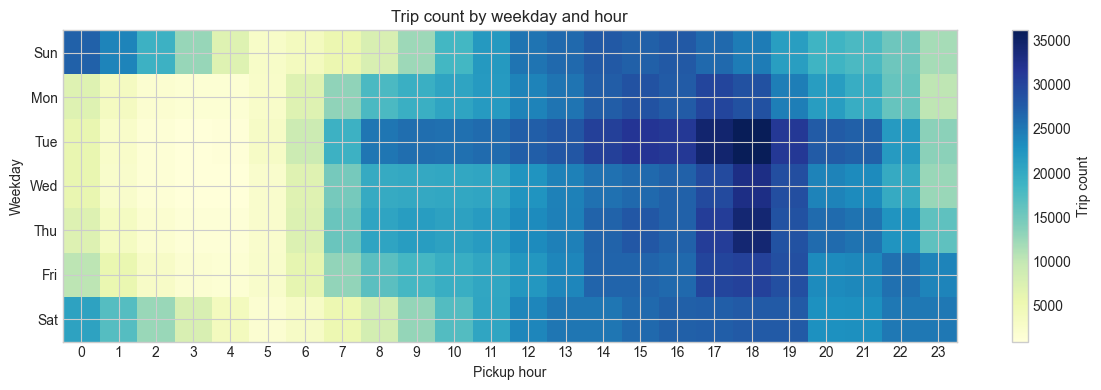

In [7]:
weekday_labels = {
    1: "Sun",
    2: "Mon",
    3: "Tue",
    4: "Wed",
    5: "Thu",
    6: "Fri",
    7: "Sat",
}
weekday_heat = weekday_hourly.pivot_table(
    index="pickup_weekday_num",
    columns="pickup_hour",
    values="trip_count",
    aggfunc="sum",
).sort_index()
weekday_heat.index = [weekday_labels.get(idx, idx) for idx in weekday_heat.index]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(weekday_heat.values, aspect="auto", cmap="YlGnBu")
ax.set_title("Trip count by weekday and hour")
ax.set_xlabel("Pickup hour")
ax.set_ylabel("Weekday")
ax.set_xticks(range(len(weekday_heat.columns)))
ax.set_xticklabels(weekday_heat.columns)
ax.set_yticks(range(len(weekday_heat.index)))
ax.set_yticklabels(weekday_heat.index)
fig.colorbar(im, ax=ax, label="Trip count")
plt.tight_layout()


## Top pickup and dropoff zones

These rankings highlight geographic concentration and help motivate zone-level forecasting rather than citywide-only forecasting.


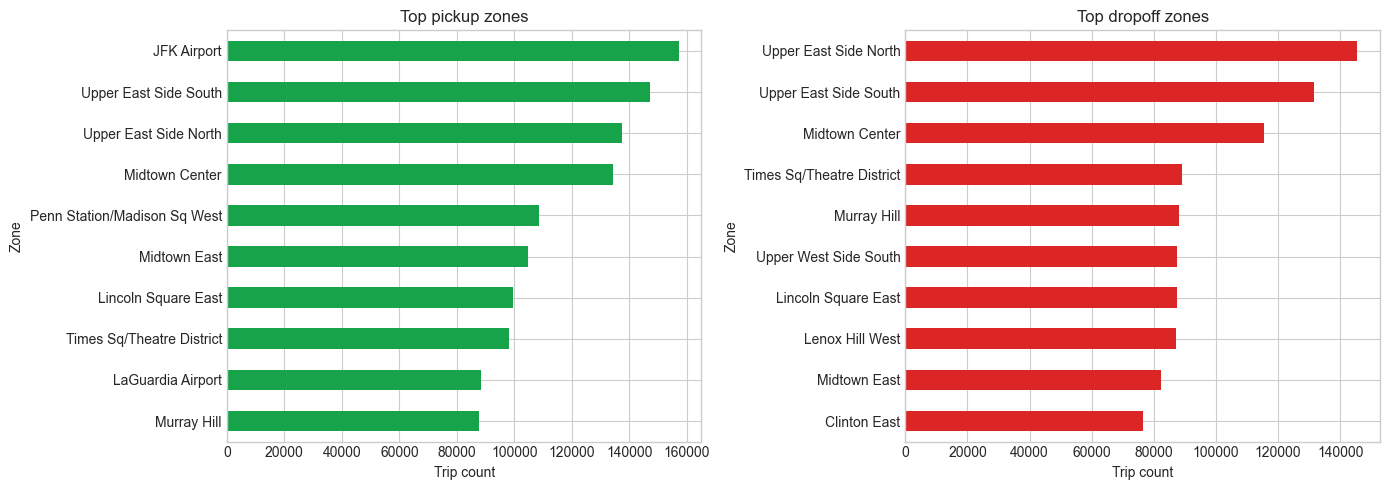

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pickup_plot = top_pickup.head(10).sort_values("trip_count")
pickup_label = "zone" if "zone" in pickup_plot.columns else "location_id"
pickup_plot.plot.barh(
    x=pickup_label,
    y="trip_count",
    ax=axes[0],
    title="Top pickup zones",
    legend=False,
    color="#16a34a",
)
axes[0].set_xlabel("Trip count")
axes[0].set_ylabel("Zone")

dropoff_plot = top_dropoff.head(10).sort_values("trip_count")
dropoff_label = "zone" if "zone" in dropoff_plot.columns else "location_id"
dropoff_plot.plot.barh(
    x=dropoff_label,
    y="trip_count",
    ax=axes[1],
    title="Top dropoff zones",
    legend=False,
    color="#dc2626",
)
axes[1].set_xlabel("Trip count")
axes[1].set_ylabel("Zone")
plt.tight_layout()


## Holiday / Special Day 
Taxi demand on New Year's Day differs from regular weekdays, indicating that special events and holidays significantly impact urban mobility patterns.

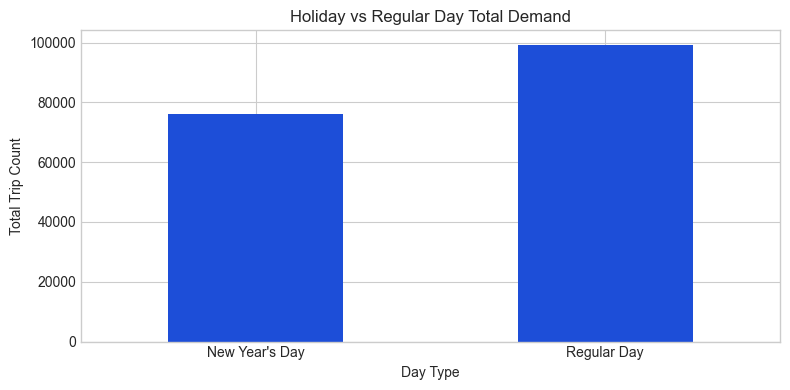

In [ ]:
df = overall_hourly.copy()
df["pickup_hour_ts"] = pd.to_datetime(df["pickup_hour_ts"])
df["date"] = df["pickup_hour_ts"].dt.date

holiday_date = pd.to_datetime("2023-01-01").date()
normal_date = pd.to_datetime("2023-01-10").date()

holiday_total = df[df["date"] == holiday_date]["trip_count"].sum()
normal_total = df[df["date"] == normal_date]["trip_count"].sum()

comparison_df = pd.DataFrame({
    "Day Type": ["New Year's Day", "Regular Day"],
    "Trip Count": [holiday_total, normal_total]
})

ax = comparison_df.plot(
    kind="bar",
    x="Day Type",
    y="Trip Count",
    legend=False,
    figsize=(8, 4),
    title="Holiday vs Regular Day Total Demand",
    color="#1d4ed8"
)

ax.set_ylabel("Total Trip Count")
plt.xticks(rotation=0)
plt.tight_layout()